# **Autoencoder Implementation**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values (0–1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape to (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [2]:
# Build Autoencoder Model

# Encoder
input_img = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(input_img)
x = layers.Dense(128, activation="relu")(x)
latent = layers.Dense(32, activation="relu")(x)  # latent representation

# Decoder
x = layers.Dense(128, activation="relu")(latent)
x = layers.Dense(28 * 28, activation="sigmoid")(x)
output_img = layers.Reshape((28, 28, 1))(x)

# Autoencoder model
autoencoder = models.Model(input_img, output_img)
autoencoder.compile(optimizer="adam", loss="mse")

In [3]:
# Training the Model
history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0907 - val_loss: 0.0313
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0280 - val_loss: 0.0196
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0189 - val_loss: 0.0159
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0160 - val_loss: 0.0142
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0143 - val_loss: 0.0129
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0131 - val_loss: 0.0120
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0123 - val_loss: 0.0115
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0116 - val_loss: 0.0110
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0112 - val_loss: 0.0107
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0108 - val_loss: 0.0104


In [4]:
# Model Summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629,906 (2.40 MB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 419,938 (1.60 MB)

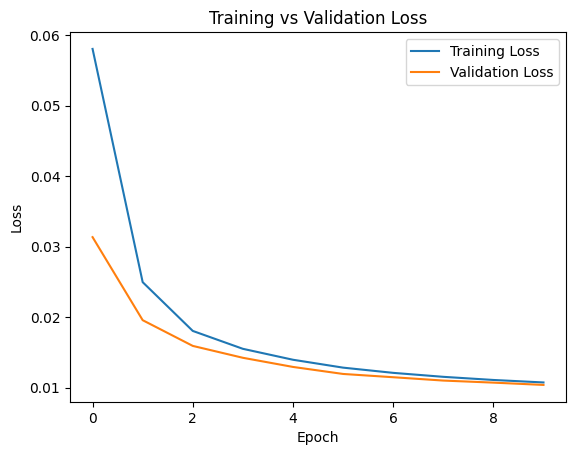

In [5]:
# Plot Training vs Validation Loss
plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.show()

**Observations**

*   Validation loss following a similar trend.
*   Indicates the model learns meaningful compression.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


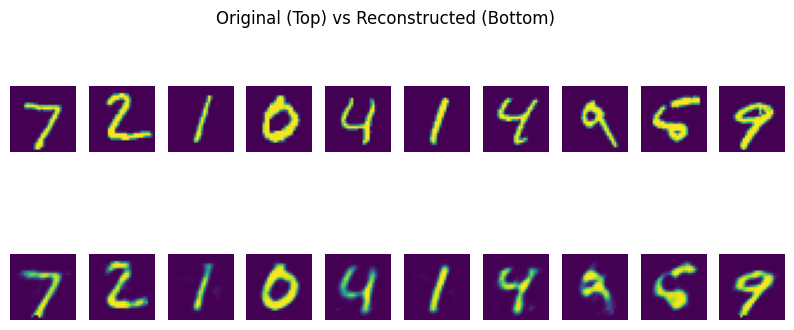

In [6]:
# Reconstruction Visualization
decoded_imgs = autoencoder.predict(x_test[:10])
plt.figure(figsize=(10, 4))

for i in range(10):
    # Original images
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.axis("off")

    # Reconstructed images
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.axis("off")

plt.suptitle("Original (Top) vs Reconstructed (Bottom)")
plt.show()

**Observations**

*   Reconstructed digits look slightly blurred but recognizable.
*   Shows the autoencoder learned key digit features.

### **Explanation**

The autoencoder successfully learned to compress and reconstruct MNIST digit images. During training, both training and validation loss decreased steadily, indicating that the model learned meaningful latent representations without significant overfitting. The latent space of size 32 was sufficient to capture essential features of handwritten digits.

The reconstructed images closely resemble the original digits, although some fine details are lost due to compression. This demonstrates that the autoencoder effectively extracts important visual patterns while discarding less relevant information. Overall, the model proves the effectiveness of neural networks in dimensionality reduction and image reconstruction tasks.